In [89]:
from matplotlib import pyplot as plt # plotting
import math
import sklearn
#import GPy

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct


import scipy
from tqdm import tqdm
import torch
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time
import torch.nn as nn

import stable_baselines3 as stable
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import LogEveryNTimesteps
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.sb2_compat.rmsprop_tf_like import RMSpropTFLike
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv

np.random.seed(101)


In [90]:
class LossRecorderCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.losses = []
        self.policy_losses = []
        self.value_losses = []
        self.entropy_losses = []
        self.log_std = []
        self.th = []
        self.omega = []
        #self.step
        
    def _on_step(self):
        # Access logger values after each training step
        if 'train/loss' in self.model.logger.name_to_value:
            self.losses.append(self.model.logger.name_to_value['train/loss'])
        if 'train/policy_loss' in self.model.logger.name_to_value:
            self.policy_losses.append(self.model.logger.name_to_value['train/policy_loss'])
        if 'train/value_loss' in self.model.logger.name_to_value:
            self.value_losses.append(self.model.logger.name_to_value['train/value_loss'])
        if 'train/entropy_loss' in self.model.logger.name_to_value:
            self.entropy_losses.append(self.model.logger.name_to_value['train/entropy_loss'])
        self.log_std.append((self.model.policy.log_std).detach().numpy())
        self.th.append((env.th)%(2*math.pi))
        self.omega.append(env.omega)
        return True


In [91]:


class sinus(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        # Assuming x has shape [batch_size, features]
        # Apply different operations to different feature indices
        x_sin = torch.sin(x[:, 0:1])  # sine of first feature
        #x_square = x[:, 1:2] ** 2     # square of second feature
        x_identity = x[:, 1:]         # pass through other features
        
        return torch.cat([x_sin, x_identity], dim=1)
    


class CustomFeatures(BaseFeaturesExtractor):
    """
    :param observation_space: (gym.Space)
    :param features_dim: (int) Number of features extracted.
        torchis corresponds to torche number of unit for torche last layer.
    """

    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 2):
        super().__init__(observation_space, features_dim)
        n_input_channels = observation_space.shape[0]
        self.network = nn.Sequential(
            sinus(),
            #nn.Linear(n_input_channels, 64),
            #nn.Tanh(),
            #nn.Linear(64, 1),
            #nn.Tanh(),
            nn.Flatten()
        )

        # Compute shape by doing one forward pass
        with torch.no_grad():
            n_flatten = self.network(
                torch.as_tensor(observation_space.sample()[None]).float()
            ).shape[1]

        #self.linear = nn.Sequential(nn.Linear(n_flatten, features_dim), nn.reLU())

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        #return self.linear(self.network(observations))
        return (self.network(observations))



In [92]:
unwrap = lambda theta: \
    -np.cos(theta)

custom_reward = lambda self: \
    unwrap(self.th) + ((self.omega/40)**2)/10 - ((self.omega/40)**2 > 0.25)
    #(- (((self.th % (2*math.pi))  - math.pi)/math.pi)**2) #- ((self.omega/40)**2)*(unwrap(self.th))
    #(unwrap(self.th)>-0.5)*(1 - (((self.th % (2*math.pi))  - math.pi)/math.pi)**2) + \
    #(unwrap(self.th)>0)*(1 - 2*(self.omega/40)**2) + \
    #((self.omega/40)**2)*((self.omega/40)<0.5) - \
    #((self.omega/40)**2)*((self.omega/40)>0.5)


env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #alternative
env.reward_fun = custom_reward

train_callback = LossRecorderCallback()

policy_kwargs = dict(activation_fn=torch.nn.Sigmoid,
                     #features_extractor_class=CustomFeatures,
                     net_arch=dict(pi=[64,64], vf=[64,64]),
                     optimizer_class=RMSpropTFLike, 
                     optimizer_kwargs=dict(eps=1e-5)
                     )

learning_rate= lambda time: 0.004#*(0.999**time) + 0.001
n_steps=64
gamma=0.98
ent_coef=0.5
vf_coef=2

policy = "MlpPolicy"

actor_crit = stable.A2C(policy, env, learning_rate=learning_rate, n_steps=n_steps, gamma=gamma, ent_coef=ent_coef, vf_coef=vf_coef, \
    max_grad_norm=0.5, use_rms_prop=False, normalize_advantage=True, stats_window_size=100, \
    tensorboard_log=None, policy_kwargs=policy_kwargs, verbose=1, _init_setup_model=True, use_sde=False)

#actor_crit = stable.PPO(policy, env, learning_rate=learning_rate, n_steps=n_steps, gamma=gamma, ent_coef=ent_coef, vf_coef=vf_coef, \
#    max_grad_norm=0.5, normalize_advantage=True, stats_window_size=100, \
#    tensorboard_log=None, policy_kwargs=policy_kwargs, verbose=1, _init_setup_model=True)

#print(actor_crit.policy)

Using cpu device

Wrapping the env with a `Monitor` wrapper

Wrapping the env in a DummyVecEnv.

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100,032/100,000  [ 0:03:07 < 0:00:00 , 479 it/s ]

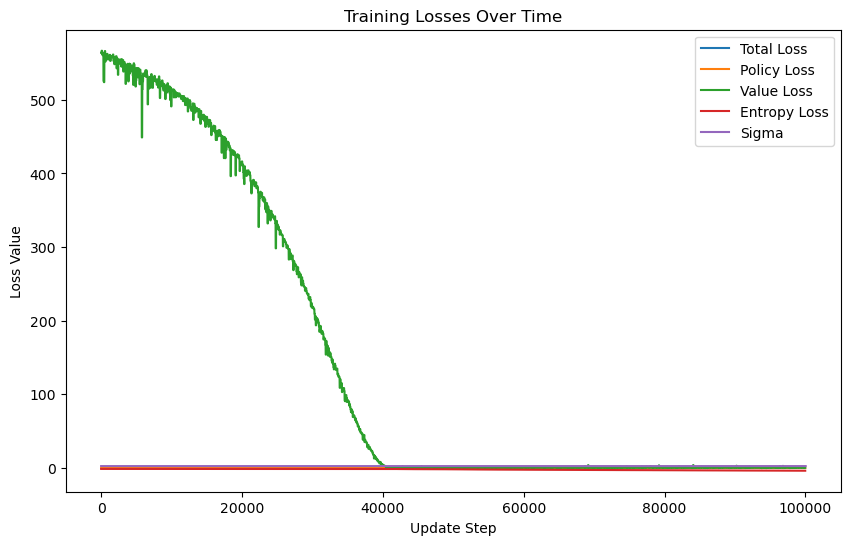

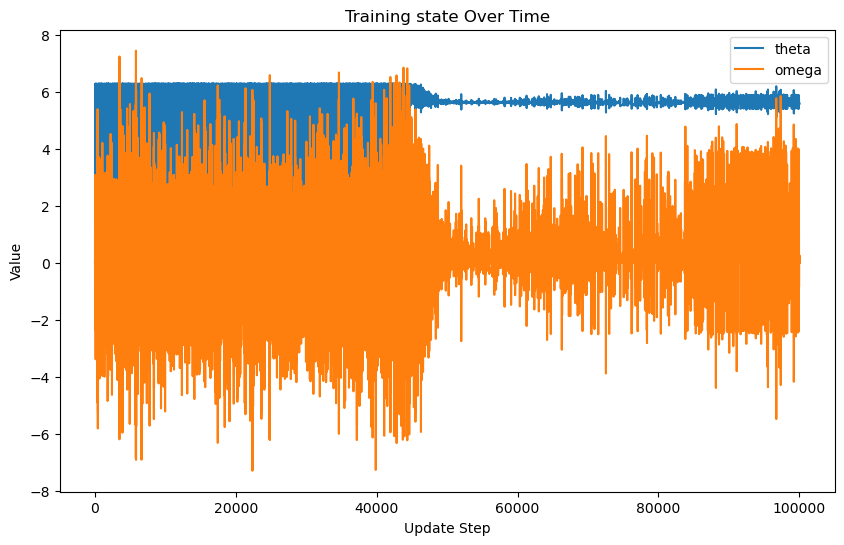

In [93]:

actor_crit.learn(total_timesteps=100_000, progress_bar=True, log_interval=10_000, callback=train_callback)
actor_crit.save("current_model")

vec_env = actor_crit.get_env()
obs = vec_env.reset()

for i in range(500):
    action, _state = actor_crit.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)
    vec_env.render("human")
    # VecEnv resets automatically
    # if done:
    #   obs = vec_env.reset()

vec_env.close()

plt.figure(figsize=(10, 6))
plt.plot((train_callback.losses), label='Total Loss')
plt.plot((train_callback.policy_losses), label='Policy Loss')
plt.plot((train_callback.value_losses), label='Value Loss')
plt.plot((train_callback.entropy_losses), label='Entropy Loss')
plt.plot((train_callback.log_std), label='Sigma')

plt.xlabel('Update Step')
plt.ylabel('Loss Value')
plt.legend()
plt.title('Training Losses Over Time')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot((train_callback.th), label='theta')
plt.plot((train_callback.omega), label='omega')

plt.xlabel('Update Step')
plt.ylabel('Value')
plt.legend()
plt.title('Training state Over Time')
plt.show()

In [94]:
vec_env.close()